# 🚖 Ride-Hailing Data Analysis: NYC Taxi Trip Insights

## 📌 Project Overview

This project focuses on analyzing NYC taxi trip data to uncover meaningful insights that can support decision-making in a ride-hailing business environment. The analysis involves data cleaning, transformation, and exploratory analysis to understand patterns in taxi operations.

## 🧠 Objective

Assuming the role of a Data Analyst in a ride-hailing company, the primary goal of this project is to analyze trip data and extract actionable insights related to:

* 🚖 **Trip Behavior** – Understanding how customers use taxi services
* 💰 **Pricing Patterns** – Analyzing fare structures and consistency
* 📊 **Demand Trends** – Identifying peak hours and high-demand periods
* ⚙️ **Operational Inefficiencies** – Detecting delays, unusual trips, and inefficiencies

## 🎯 Key Goal

To transform raw taxi trip data into meaningful insights that can help improve pricing strategies, optimize operations, and enhance customer experience.

---


In [38]:
#(1)Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [39]:
#(2)Load Dataset & Sample 45K Rows
df = pd.read_excel("/content/yellow_tripdata_2020-06.xlsx")

# Random 45k rows
df = df.sample(n=45000, random_state=42)

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
126223,2.0,2020-06-10 13:36:49,2020-06-10 13:51:08,1.0,2.73,1.0,N,224,148,2.0,12.00,0.0,0.5,0.00,0.00,0.3,15.30,2.5
519501,NaN,2020-06-13 06:19:00,2020-06-13 06:37:00,NaN,11.58,NaN,NaN,56,42,NaN,28.81,0.0,0.5,0.00,6.12,0.3,35.73,0.0
284266,2.0,2020-06-20 07:59:23,2020-06-20 08:05:39,1.0,2.05,1.0,N,79,68,2.0,8.00,0.0,0.5,0.00,0.00,0.3,11.30,2.5
431328,1.0,2020-06-27 15:11:32,2020-06-27 15:15:02,1.0,1.40,1.0,N,236,75,1.0,6.00,2.5,0.5,1.85,0.00,0.3,11.15,2.5
414269,1.0,2020-06-26 16:00:36,2020-06-26 16:02:28,1.0,0.60,1.0,N,186,90,2.0,4.00,3.5,0.5,0.00,0.00,0.3,8.30,2.5


In [40]:
#(3)Initial Exploration
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (45000, 18)

Data Types:
 VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

Missing Values:
 VendorID                 4223
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          4223
trip_distance               0
RatecodeID               4223
store_and_fwd_flag       4223
PULoc

In [41]:
#Separate columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
datetime_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')
Categorical: Index(['store_and_fwd_flag'], dtype='object')


In [42]:
#(4)NumPy-Based Analysis
for col in ['trip_distance', 'fare_amount', 'total_amount']:
    data = df[col].dropna().values
    print(f"\n{col}")
    print("Mean:", np.mean(data))
    print("Median:", np.median(data))
    print("Std Dev:", np.std(data))


trip_distance
Mean: 3.3729604444444443
Median: 1.87
Std Dev: 4.298907623544461

fare_amount
Mean: 13.647337111111112
Median: 9.0
Std Dev: 13.443682721971044

total_amount
Mean: 18.839376444444447
Median: 14.16
Std Dev: 15.067954672603145


In [43]:
#(5)Data Type Conversion
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [44]:
#(6)Missing Value Handling
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())
df['trip_distance'] = df['trip_distance'].fillna(df['trip_distance'].median())
df['tip_amount'] = df['tip_amount'].fillna(0)
df['payment_type'] = df['payment_type'].fillna(df['payment_type'].mode()[0])

In [45]:
#(7)Remove Invalid Records
df = df[
    (df['passenger_count'] > 0) &
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0)
].copy()

In [46]:
#(8)Remove Duplicates
df = df.drop_duplicates()

In [47]:
#(9)Categorical Cleaning
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].str.upper().str.strip()
df['payment_type'] = df['payment_type'].astype(str).str.strip()

In [48]:
#(10)Datetime Feature Engineering
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['month'] = df['tpep_pickup_datetime'].dt.month

In [49]:
#(11)Trip Duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Remove invalid durations
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 300)]

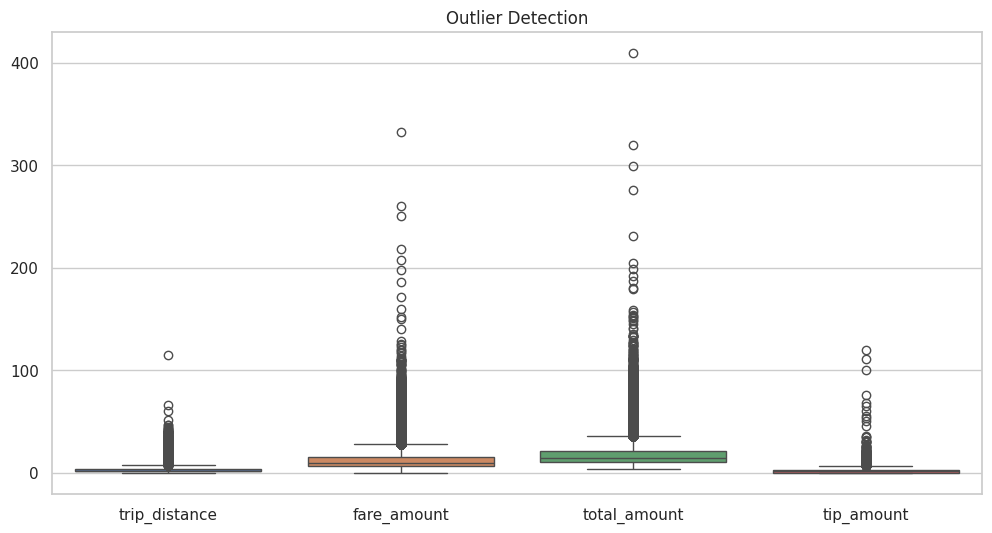

In [50]:
#(12)Outlier Detection (Boxplots)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['trip_distance','fare_amount','total_amount','tip_amount']])
plt.title("Outlier Detection")
plt.show()

In [51]:
#(13)Feature Engineering
df['fare_per_km'] = df['fare_amount'] / df['trip_distance']
df['tip_percentage'] = (df['tip_amount'] / df['fare_amount']) * 100
df['trip_speed'] = df['trip_distance'] / (df['trip_duration'] / 60)

In [52]:
#(14)Final Validation
print(df.describe())
print(df.isnull().sum())

           VendorID           tpep_pickup_datetime  \
count  38213.000000                          42306   
mean       1.622642  2020-06-17 08:30:08.340921088   
min        1.000000            2009-01-01 01:04:51   
25%        1.000000  2020-06-10 09:17:37.249999872   
50%        2.000000            2020-06-18 09:05:22   
75%        2.000000     2020-06-24 19:58:07.500000   
max        2.000000            2020-06-30 23:58:51   
std        0.484732                            NaN   

               tpep_dropoff_datetime  passenger_count  trip_distance  \
count                          42306     42306.000000   42306.000000   
mean   2020-06-17 08:42:27.920531200         1.360753       3.494861   
min              2009-01-01 01:20:53         1.000000       0.010000   
25%       2020-06-10 09:29:31.500000         1.000000       1.100000   
50%       2020-06-18 09:13:04.500000         1.000000       1.920000   
75%    2020-06-24 20:10:12.750000128         1.000000       3.800000   
max      

📊 SECTION 2: EDA

In [22]:
#1. Overall Stats
print("Total Trips:", len(df))
print("Average Fare:", df['fare_amount'].mean())
print("Average Distance:", df['trip_distance'].mean())

Total Trips: 42306
Average Fare: 13.59709875667754
Average Distance: 3.4948612489954143


In [ ]:
#2.univarate analysis
df['trip_distance'].hist(bins=50)
plt.title("Trip Distance Distribution")
plt.show()

df['fare_amount'].hist(bins=50)
plt.title("Fare Distribution")
plt.show()

sns.countplot(x='passenger_count', data=df)
plt.title("Passenger Count")
plt.show()

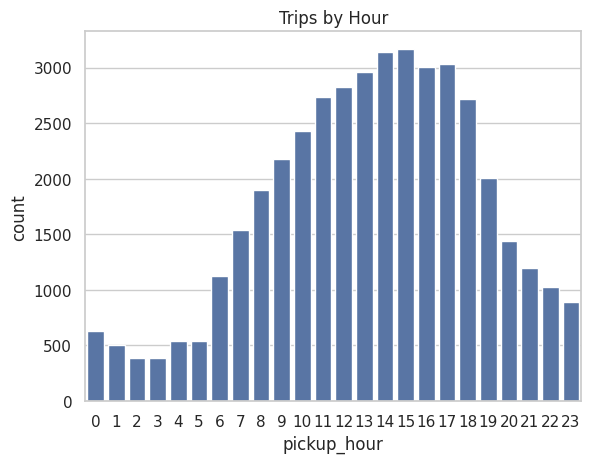

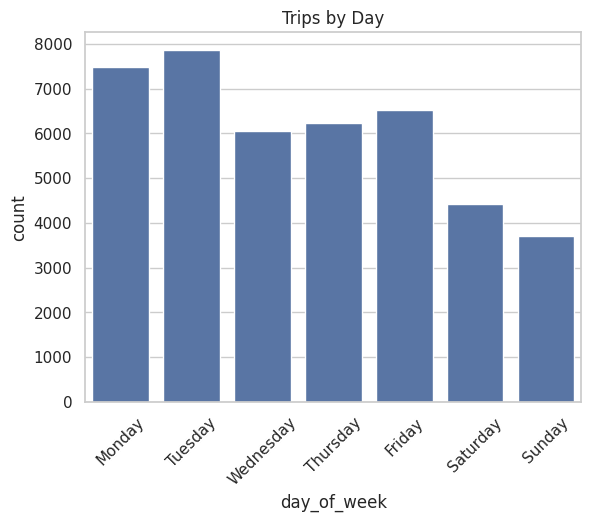

In [23]:
#3.Time-Based Analysis
sns.countplot(x='pickup_hour', data=df)
plt.title("Trips by Hour")
plt.show()

sns.countplot(x='day_of_week', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Trips by Day")
plt.xticks(rotation=45)
plt.show()

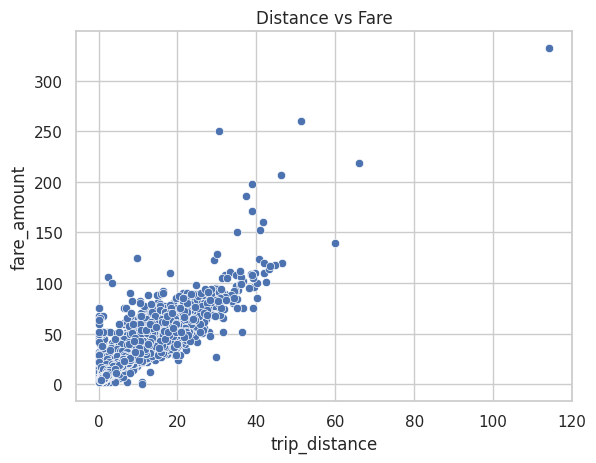

In [24]:
#4(Distance vs Fare)
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title("Distance vs Fare")
plt.show()

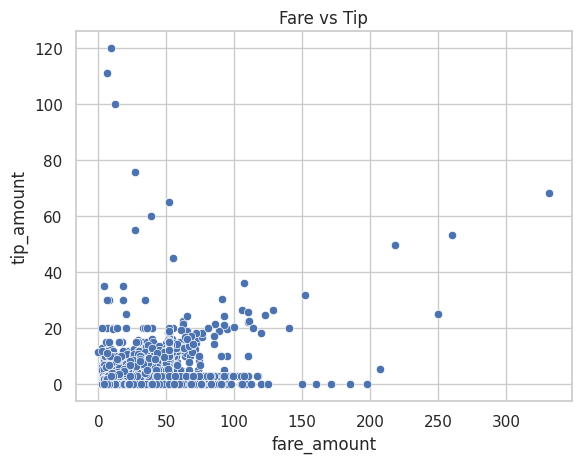

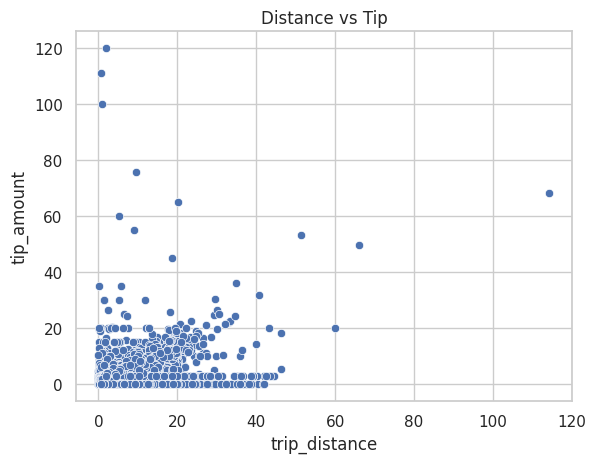

In [25]:
#(5)Tip Analysis
sns.scatterplot(x='fare_amount', y='tip_amount', data=df)
plt.title("Fare vs Tip")
plt.show()

sns.scatterplot(x='trip_distance', y='tip_amount', data=df)
plt.title("Distance vs Tip")
plt.show()

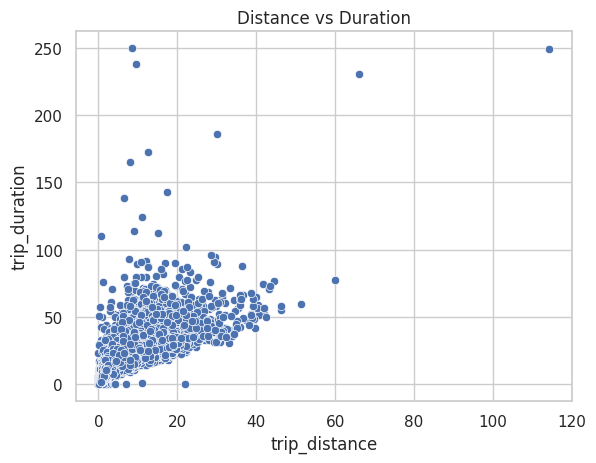

In [26]:
#(6)Duration Analysis
sns.scatterplot(x='trip_distance', y='trip_duration', data=df)
plt.title("Distance vs Duration")
plt.show()

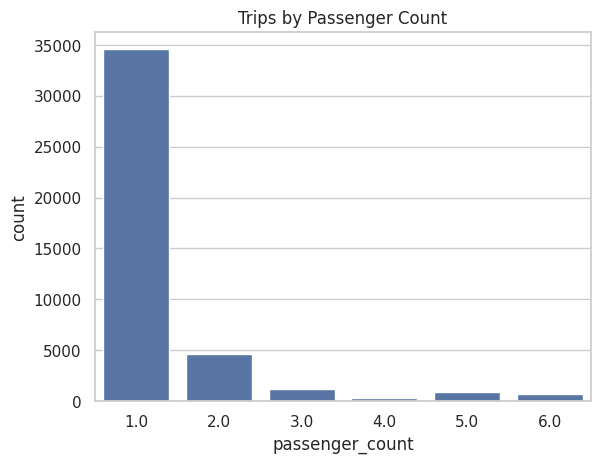

In [27]:
#(7)Passenger Analysis
sns.countplot(x='passenger_count', data=df)
plt.title("Trips by Passenger Count")
plt.show()

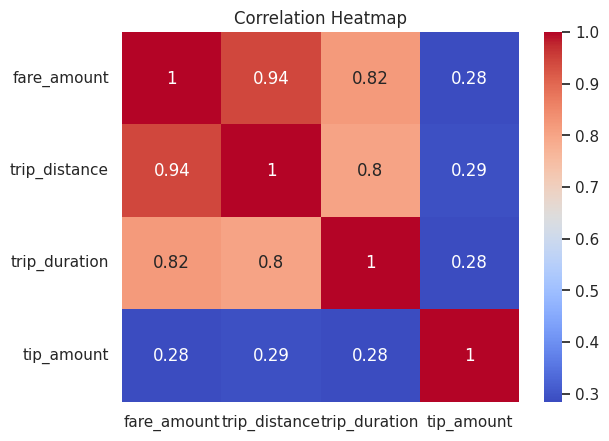

In [28]:
#(9)Correlation Heatmap
corr = df[['fare_amount','trip_distance','trip_duration','tip_amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

SECTION 3: INSIGHTS

In [29]:
#(1)Basic
print("Avg Distance:", df['trip_distance'].mean())
print("Avg Fare:", df['fare_amount'].mean())

Avg Distance: 3.4948612489954143
Avg Fare: 13.59709875667754


In [31]:
#(2)Trip Behavior
print("Most common passenger:", df['passenger_count'].mode()[0])

Most common passenger: 1.0


In [32]:
#(3)Time Insights
print("Peak Hour:", df['pickup_hour'].mode()[0])
print("Highest Demand Day:", df['day_of_week'].mode()[0])

Peak Hour: 15
Highest Demand Day: Tuesday


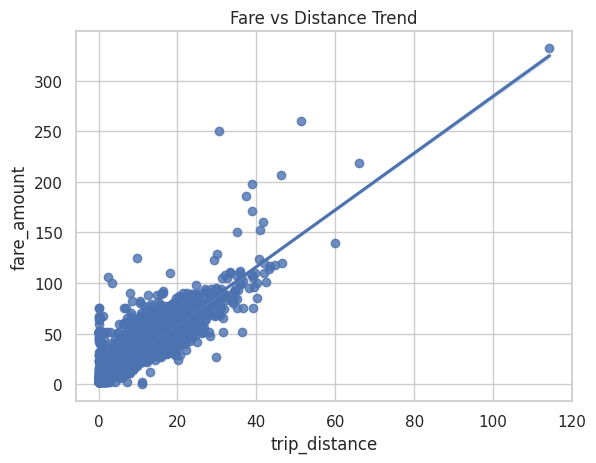

In [33]:
#(4)Pricing
sns.regplot(x='trip_distance', y='fare_amount', data=df)
plt.title("Fare vs Distance Trend")
plt.show()

In [34]:
#tips
print("Trips with no tip:", len(df[df['tip_amount']==0]))

Trips with no tip: 16621


In [35]:
#operational
weekday = df[df['day_of_week'].isin(['Monday','Tuesday','Wednesday','Thursday','Friday'])]
weekend = df[df['day_of_week'].isin(['Saturday','Sunday'])]

print("Weekday Trips:", len(weekday))
print("Weekend Trips:", len(weekend))

Weekday Trips: 34184
Weekend Trips: 8122


In [36]:
#Outliers
print("High Fare Trips:")
print(df[df['fare_amount'] > df['fare_amount'].quantile(0.99)])

High Fare Trips:
        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
532380       NaN  2020-06-20 01:00:00   2020-06-20 01:27:00              1.0   
281783       2.0  2020-06-19 22:07:31   2020-06-19 22:38:41              1.0   
492106       1.0  2020-06-30 16:30:26   2020-06-30 18:05:14              1.0   
398999       2.0  2020-06-26 01:34:22   2020-06-26 02:26:28              1.0   
446003       2.0  2020-06-28 15:28:31   2020-06-28 16:20:27              1.0   
...          ...                  ...                   ...              ...   
548656       NaN  2020-06-30 04:44:56   2020-06-30 05:20:14              1.0   
523478       NaN  2020-06-16 04:29:27   2020-06-16 04:56:23              1.0   
500249       NaN  2020-06-01 05:33:38   2020-06-01 06:15:13              1.0   
536998       NaN  2020-06-23 02:12:22   2020-06-23 02:47:03              1.0   
539450       NaN  2020-06-24 04:41:50   2020-06-24 05:14:45              1.0   

        trip_distance 

In [37]:
#Advanced Insights
inefficient = df[(df['trip_duration'] > 60) & (df['trip_distance'] < 2)]
print("Inefficient Trips:", len(inefficient))

Inefficient Trips: 2
